In [1]:
from nba_api.stats import endpoints
import pandas as pd

response = endpoints.SynergyPlayTypes(play_type_nullable='Transition', player_or_team_abbreviation='P', type_grouping_nullable='Offensive')
transition_df = response.get_data_frames()[0]
response = endpoints.SynergyPlayTypes(play_type_nullable='Isolation', player_or_team_abbreviation='P', type_grouping_nullable='Offensive')
isolation_df = response.get_data_frames()[0]
response = endpoints.SynergyPlayTypes(play_type_nullable='PRBallHandler', player_or_team_abbreviation='P', type_grouping_nullable='Offensive')
PNRBH_df = response.get_data_frames()[0]
response = endpoints.SynergyPlayTypes(play_type_nullable='PRRollman', player_or_team_abbreviation='P', type_grouping_nullable='Offensive')
PNRRM_df = response.get_data_frames()[0]
response = endpoints.SynergyPlayTypes(play_type_nullable='OffRebound', player_or_team_abbreviation='P', type_grouping_nullable='Offensive')
Putback_df = response.get_data_frames()[0]
response = endpoints.SynergyPlayTypes(play_type_nullable='Spotup', player_or_team_abbreviation='P', type_grouping_nullable='Offensive')
Spotup_df = response.get_data_frames()[0]
response = endpoints.SynergyPlayTypes(play_type_nullable='Cut', player_or_team_abbreviation='P', type_grouping_nullable='Offensive')
Cut_df = response.get_data_frames()[0]
response = endpoints.SynergyPlayTypes(play_type_nullable='Handoff', player_or_team_abbreviation='P', type_grouping_nullable='Offensive')
Handoff_df = response.get_data_frames()[0]
response = endpoints.SynergyPlayTypes(play_type_nullable='OffScreen', player_or_team_abbreviation='P', type_grouping_nullable='Offensive')
OffScreen_df = response.get_data_frames()[0]
response = endpoints.SynergyPlayTypes(play_type_nullable='Misc', player_or_team_abbreviation='P', type_grouping_nullable='Offensive')
Misc_df = response.get_data_frames()[0]
response = endpoints.SynergyPlayTypes(play_type_nullable='Postup', player_or_team_abbreviation='P', type_grouping_nullable='Offensive')
Postup_df = response.get_data_frames()[0]
dfs = [transition_df, isolation_df, PNRBH_df, PNRRM_df, Putback_df, Spotup_df, Cut_df, Handoff_df, OffScreen_df, Misc_df, Postup_df]
combined_df = pd.concat(dfs, ignore_index=True)
pivot_df = combined_df.pivot_table(index='PLAYER_NAME',  # Player name as index
                                   columns='PLAY_TYPE',  # Play types as separate columns
                                   values='PTS',  # Fill with points per game
                                   aggfunc='first'  # Assuming you want to keep the first encountered value if there's any duplicate
                                  ).reset_index()
player_team_df = combined_df.groupby('PLAYER_NAME')['TEAM_ABBREVIATION'].agg('first').reset_index()

# Step 2: Merge the team information with pivot_df
pivot_df = pd.merge(pivot_df, player_team_df, on='PLAYER_NAME', how='left')

# The pivot_df now has one row per player with each play type's points per game as separate columns.
sums = pivot_df.drop(['PLAYER_NAME','TEAM_ABBREVIATION'], axis=1).sum(axis=1)

pivot_df['Sum'] = sums
playtypes = ['Cut', 'Isolation', 'PRRollMan', 'PRBallHandler', 'OffRebound', 'Spotup', 'Handoff', 'OffScreen', 'Misc', 'Postup','Transition']

for playtype in playtypes:
    percentage_column_name = playtype + '%' 
    pivot_df[percentage_column_name] = pivot_df[playtype] / pivot_df['Sum'] * 100  
pivot_df.drop(playtypes, axis=1, inplace=True)
pivot_df.drop('Sum',axis = 1, inplace=True)
pivot_df.fillna(0, inplace=True)
pivot_df

,PLAYER_NAME,TEAM_ABBREVIATION,Cut%,Isolation%,PRRollMan%,PRBallHandler%,OffRebound%,Spotup%,Handoff%,OffScreen%,Misc%,Postup%,Transition%
0,A.J. Lawson,TOR,13.875598,0.000000,0.000000,6.698565,0.000000,40.191388,5.263158,0.000000,0.000000,0.000000,33.971292
1,AJ Green,MIL,0.000000,0.000000,0.000000,3.517588,0.000000,60.050251,24.120603,9.547739,2.763819,0.000000,0.000000
2,AJ Johnson,WAS,0.000000,9.659091,0.000000,28.977273,0.000000,26.704545,0.000000,0.000000,1.136364,0.000000,33.522727
3,Aaron Gordon,DEN,19.328859,6.442953,4.697987,7.382550,8.859060,16.375839,2.550336,0.000000,1.879195,12.483221,20.000000
4,Aaron Holiday,HOU,0.000000,6.716418,0.000000,55.970149,0.000000,0.000000,10.447761,17.910448,8.955224,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
444,Zach Edey,MEM,0.000000,0.000000,0.000000,0.000000,57.564576,0.000000,0.000000,0.000000,7.011070,35.424354,0.000000
445,Zach LaVine,CHI,4.607843,16.960784,0.980392,23.333333,0.000000,14.607843,6.764706,2.450980,1.176471,3.039216,26.078431
446,Zeke Nnaji,DEN,21.348315,0.000000,11.235955,0.000000,11.797753,28.089888,0.000000,0.000000,0.000000,0.000000,27.528090
447,Ziaire Williams,BKN,7.223114,0.000000,1.444623,2.728732,7.062600,43.659711,5.617978,1.926164,3.852327,0.000000,26.484751


In [21]:
cands_df = endpoints.LeagueDashPlayerPtShot(general_range_nullable = 'Catch and Shoot').get_data_frames()[0]
pullups_df = endpoints.LeagueDashPlayerPtShot(general_range_nullable = 'Pullups').get_data_frames()[0]
within10_df = endpoints.LeagueDashPlayerPtShot(general_range_nullable = 'Less Than 10 ft').get_data_frames()[0]

shooting_df = pd.merge(cands_df,pullups_df, on = "PLAYER_NAME", how = 'inner')
shooting_df = pd.merge(shooting_df, within10_df, on = 'PLAYER_NAME', how = 'inner')
shooting_df = shooting_df[[col for col in shooting_df.columns if 'FGA_FREQUENCY' in col or 'PLAYER_NAME' in col]]
shooting_df = shooting_df.rename(columns={"FGA_FREQUENCY_x": "FREQ_CANDS", "FGA_FREQUENCY_y": "FREQ_PULLUP", "FGA_FREQUENCY": "FREQ_WITHIN10"})

traditional_df = endpoints.LeagueDashPlayerStats(measure_type_detailed_defense='Base').get_data_frames()[0]
traditional_df['FTA/MIN'] = traditional_df['FTA'] / traditional_df['MIN']
traditional_df = traditional_df[['PLAYER_NAME', 'FTA/MIN']]


In [35]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from kneed import KneeLocator

player_df = pivot_df.copy()
scoring_df = endpoints.LeagueDashPlayerStats(measure_type_detailed_defense='Scoring').get_data_frames()[0]
scoring_df = scoring_df[scoring_df["GP"] > 20]
scoring_df = scoring_df[scoring_df["MIN"] > 15]
usage_df = endpoints.LeagueDashPlayerStats(measure_type_detailed_defense='Usage').get_data_frames()[0]
usage_df['MIN/G'] = usage_df['MIN'] / usage_df['GP']
usage_df = usage_df[usage_df["GP"] > 20]
usage_df = usage_df[usage_df['MIN/G'] > 15]
usage_df = usage_df[['PLAYER_NAME', 'USG_PCT']]
remove = [col for col in scoring_df.columns if 'PCT' not in col and col != 'PLAYER_NAME']
scoring_df.drop(columns  = remove, inplace = True, axis = 1)

zone_df = endpoints.LeagueDashPlayerShotLocations(distance_range = 'By Zone').get_data_frames()[0]
new_columns = [f'{col[0]}_{col[1]}' if col[0] else col[1] for col in zone_df.columns]

new_columns = [col.strip('_') for col in new_columns]
 
zone_df.columns = new_columns

removed_columns = [col for col in new_columns if 'Backcourt' in col or ('FGA' not in col and 'PLAYER_NAME' not in col) or 'Left' in col or 'Right' in col]

zone_df.drop(columns = removed_columns, inplace = True, axis = 1)

zone_df['Sum'] = zone_df.drop(['PLAYER_NAME'], axis=1).sum(axis=1)

columns  = [col for col in zone_df.columns if 'FGA' in col]
for column in columns:
    zone_df[column] = zone_df[column] / zone_df['Sum']
    
del zone_df['Sum']

bio_df = endpoints.LeagueDashPlayerBioStats().get_data_frames()[0]
bio_df = bio_df[['PLAYER_NAME', 'PLAYER_HEIGHT_INCHES']]

drives_df = pd.read_excel(r"cache\drives_nba.xlsx")
#drives_df = pd.read_excel(r"C:\Users\chris\OneDrive\Documents\drives_nba.xlsx")
drives_df['Drives/Min'] = drives_df['DRIVES'] / drives_df['MIN']
drives_df['PLAYER_NAME'] = drives_df['PLAYER']
drives_df = drives_df[['PLAYER_NAME','Drives/Min']]

#merged_df = pd.merge(pivot_df, zone_df, on='PLAYER_NAME', how='left')
#merged_df = pd.merge(merged_df,scoring_df, on= 'PLAYER_NAME', how = 'inner')
merged_df = pd.merge(pivot_df,usage_df, on= 'PLAYER_NAME', how = 'left')
merged_df = pd.merge(merged_df,bio_df, on= 'PLAYER_NAME', how = 'left')
merged_df = pd.merge(merged_df,drives_df, on= 'PLAYER_NAME', how = 'left')
merged_df = pd.merge(merged_df, shooting_df, on = 'PLAYER_NAME', how = 'left')
merged_df = pd.merge(merged_df, traditional_df, on = 'PLAYER_NAME', how = 'left')
columns  = [col for col in merged_df.columns if 'RANK' in col or 'W_PCT' in col or 'TEAM_ABBREVIATION' in col]
merged_df.drop(columns = columns, inplace = True, axis = 1)
#del merged_df['PCT_UAST_3PM']
#del merged_df['PCT_AST_3PM']
del merged_df['Misc%']
#del merged_df['FG_PCT']




,silhouette,davies_bouldin,inertia
k,,,
2,0.268857,1.449092,4948.573700
3,0.284783,1.246259,3695.700072
4,0.226406,1.532002,3416.952393
5,0.264238,1.359082,3154.483516
6,0.198839,1.387633,2897.079299
7,0.228755,1.270328,2557.561972
8,0.219955,1.322544,2314.688706
9,0.212494,1.346090,2198.402680
10,0.194682,1.431850,2136.141964


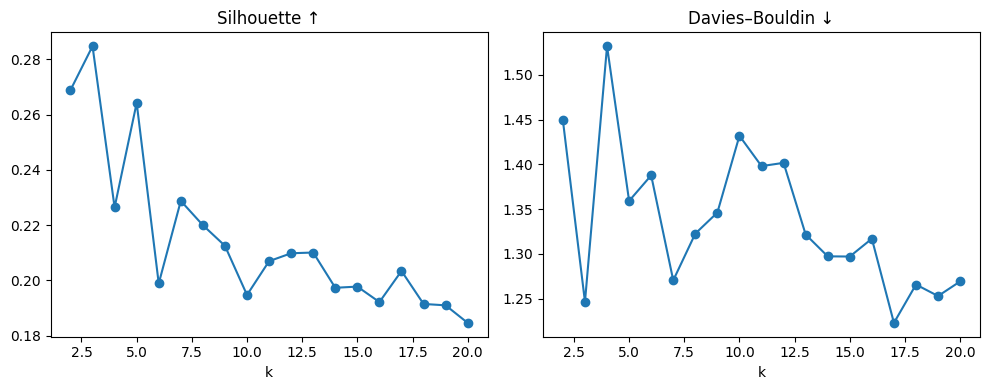

Top-3 by quality ➜ [3, 2, 5]
Bootstrapped Jaccard ≥ 0.75 is healthy:
 k=3   Jaccard=0.951
 k=2   Jaccard=0.726
 k=5   Jaccard=0.490

Selected k = 3


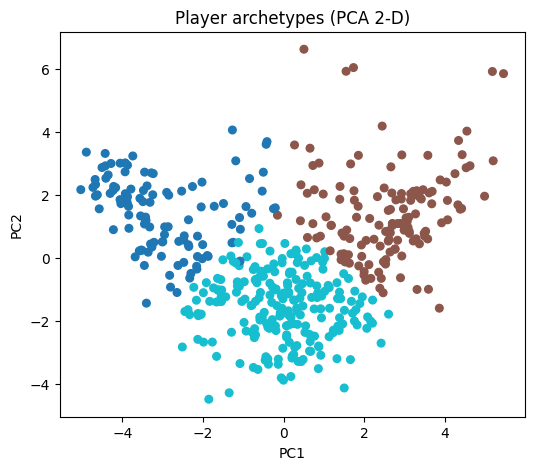


Cluster 0  (114 players):
['Aaron Gordon', 'Adem Bona', 'Alex Len', 'Alex Sarr', 'Alperen Sengun', 'Amen Thompson', 'Andre Drummond', 'Anthony Davis', 'Ausar Thompson', 'Bam Adebayo', 'Ben Simmons', 'Bismack Biyombo', 'Bobby Portis', 'Brandon Clarke', 'Brook Lopez', 'Charles Bassey', 'Chet Holmgren', 'Clint Capela', 'Colin Castleton', 'Daniel Gafford', 'Daniel Theis', 'Dario Šarić', "Day'Ron Sharpe", 'DeAndre Jordan', 'Deandre Ayton', 'Dereck Lively II', 'Domantas Sabonis', 'Dominick Barlow', 'Donovan Clingan', 'Drew Eubanks', 'Drew Timme', 'Dwight Powell', 'Evan Mobley', 'Gary Payton II', 'Goga Bitadze', 'Guerschon Yabusele', 'Isaac Okoro', 'Isaiah Hartenstein', 'Isaiah Stewart', 'Ivica Zubac', 'JT Thor', 'Jabari Walker', 'Jakob Poeltl', 'Jalen Duren', 'Jalen Smith', 'Jarred Vanderbilt', 'Jarrett Allen', 'Jaxson Hayes', 'Jay Huff', 'Jaylin Williams', 'Jeremy Sochan', 'Jericho Sims', 'Jock Landale', 'Joel Embiid', 'John Collins', 'Jonas Valančiūnas', 'Jonathan Isaac', 'Jonathan Mogbo'

,Arch_0,Arch_1,Arch_2
PLAYER_NAME,,,
A.J. Lawson,5.351668e-05,0.004250,0.995696
AJ Green,7.131335e-09,0.026813,0.973187
AJ Johnson,9.256750e-05,0.182243,0.817665
Aaron Gordon,1.366577e-01,0.028858,0.834484
Aaron Holiday,2.936113e-11,0.993602,0.006398


In [30]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
)
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0.  Prepare feature matrix X and player index  -------------
# ------------------------------------------------------------
X = merged_df.drop(columns=['PLAYER_NAME'])
player_index = merged_df['PLAYER_NAME']          # keep for later

num_cols = X.columns.tolist()                   # all numeric after merges

# ------------------------------------------------------------
# 1.  Build preprocessing + PCA pipeline  --------------------
# ------------------------------------------------------------
prep = ColumnTransformer(
    [("num", Pipeline([
        ("impute", SimpleImputer(strategy="mean")),
        ("scale",  StandardScaler())
    ]), num_cols)],
    remainder="drop"
)

pca = PCA(n_components=0.80, svd_solver="full")  # keep 80 % var
base_pipe = Pipeline([
    ("prep", prep),
    ("pca",  pca),
])

X_emb = base_pipe.fit_transform(X)              # cached embedding

# ------------------------------------------------------------
# 2.  Sweep k = 2‒20  (quality metrics)  ---------------------
# ------------------------------------------------------------
def quality_table(X_, ks=range(2, 21), rng=0):
    rows = []
    for k in ks:
        km = KMeans(n_clusters=k, init="k-means++", random_state=rng)
        labels = km.fit_predict(X_)
        rows.append({
            "k": k,
            "silhouette": silhouette_score(X_, labels),
            "davies_bouldin": davies_bouldin_score(X_, labels),
            "inertia": km.inertia_
        })
    return pd.DataFrame(rows)

qtab = quality_table(X_emb)
display(qtab.set_index("k"))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(qtab["k"], qtab["silhouette"], marker="o"); ax[0].set_title("Silhouette ↑")
ax[1].plot(qtab["k"], qtab["davies_bouldin"], marker="o"); ax[1].set_title("Davies–Bouldin ↓")
for a in ax: a.set_xlabel("k")
plt.tight_layout(); plt.show()

# pick candidate k where silhouette local-max & D-B local-min
k_candidates = qtab.sort_values(["silhouette", "davies_bouldin"], ascending=[False, True]).head(3)["k"].tolist()
print("Top-3 by quality ➜", k_candidates)

# ------------------------------------------------------------
# 3.  Cluster-stability via bootstrapped Jaccard  ------------
# ------------------------------------------------------------
def jaccard_sim(lab1, lab2):
    # Hungarian match for max overlap then mean Jaccard
    u, v = lab1.max()+1, lab2.max()+1
    cm = np.zeros((u, v), int)
    for a, b in zip(lab1, lab2): cm[a, b] += 1
    cost = cm.max() - cm
    r, c = linear_sum_assignment(cost)
    inter = cm[r, c]
    union = cm.sum(axis=1)[r] + cm.sum(axis=0)[c] - inter
    return np.mean(inter / union)

def stability_score(X_, k, n_boot=30, frac=0.80, rng=0):
    rng = np.random.default_rng(rng)
    km = KMeans(n_clusters=k, random_state=0).fit(X_)
    base = km.labels_
    jac = []
    for _ in range(n_boot):
        idx = rng.choice(len(X_), int(frac*len(X_)), replace=True)
        jac.append(jaccard_sim(base[idx], km.fit_predict(X_[idx])))
    return np.mean(jac)

stab = {k: stability_score(X_emb, k) for k in k_candidates}
print("Bootstrapped Jaccard ≥ 0.75 is healthy:")
for k, s in stab.items(): print(f" k={k:<2d}  Jaccard={s:.3f}")

# choose final_k with both good quality & stability
final_k = max(stab, key=stab.get)
print(f"\nSelected k = {final_k}")

# ------------------------------------------------------------
# 4.  Fit final K-means & attach labels  ---------------------
# ------------------------------------------------------------
kmeans = KMeans(n_clusters=final_k, random_state=0).fit(X_emb)
merged_df["Cluster"] = kmeans.labels_

# quick PCA scatter (1st two PCs just for eyeballing)
plt.figure(figsize=(6, 5))
plt.scatter(X_emb[:, 0], X_emb[:, 1], c=kmeans.labels_, cmap="tab10", s=30)
plt.title("Player archetypes (PCA 2-D)")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.show()

# view rosters
for c in range(final_k):
    print(f"\nCluster {c}  ({(merged_df['Cluster']==c).sum()} players):")
    print(merged_df.loc[merged_df["Cluster"]==c, "PLAYER_NAME"].to_list())

# ------------------------------------------------------------
# 5.  Optional: Gaussian-Mixture soft archetypes -------------
# ------------------------------------------------------------
gmm = GaussianMixture(n_components=final_k, covariance_type="diag", random_state=0).fit(X_emb)
prob = pd.DataFrame(gmm.predict_proba(X_emb),
                    columns=[f"Arch_{i}" for i in range(final_k)],
                    index=player_index)
prob.head()



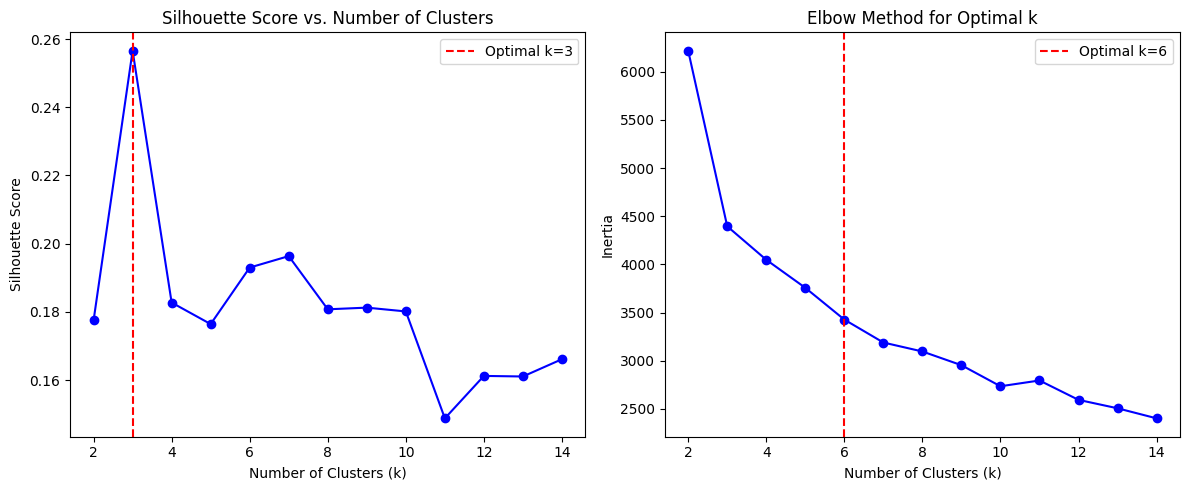

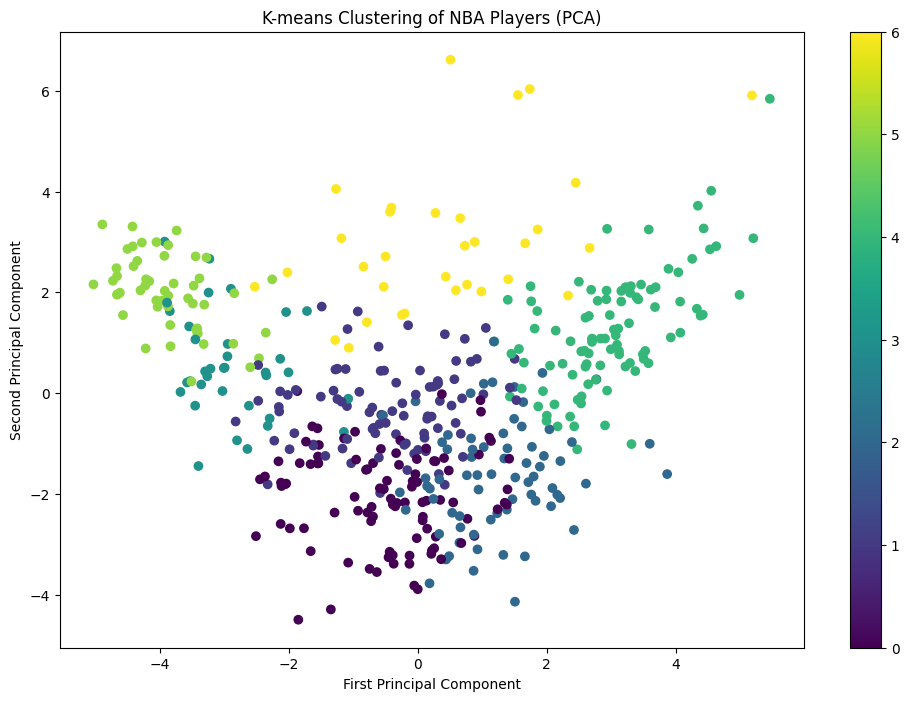


Cluster 0:
['Al Horford', 'Alex Reese', 'Amir Coffey', 'Baylor Scheierman', 'Ben Sheppard', 'Bol Bol', 'Caleb Houstan', 'Cam Reddish', 'Cason Wallace', 'Chris Boucher', 'Chuma Okeke', 'Cody Williams', 'Cole Swider', 'Cory Joseph', 'DaQuan Jeffries', 'Daeqwon Plowden', 'Dariq Whitehead', "De'Anthony Melton", 'Dean Wade', 'Delon Wright', 'Dillon Brooks', 'Dorian Finney-Smith', 'Draymond Green', 'Dru Smith', 'Duop Reath', 'Elijah Harkless', 'Eric Gordon', 'Gary Harris', 'Georges Niang', 'Gui Santos', 'Herbert Jones', 'JT Thor', 'Jabari Smith Jr.', 'Jaden McDaniels', 'Jae Crowder', 'Jake LaRavia', 'Jalen Pickett', 'Jalen Wilson', 'Jamal Cain', 'Jarace Walker', 'Javonte Green', 'Jaylen Nowell', 'Jaylen Sims', 'Jaylen Wells', 'Jeff Green', 'Jeremiah Robinson-Earl', 'Jordan Goodwin', 'Josh Richardson', 'Jrue Holiday', 'Julian Champagnie', 'Justin Edwards', 'Keegan Murray', 'Keon Ellis', 'Kessler Edwards', 'Killian Hayes', 'Kris Dunn', 'Larry Nance Jr.', 'Lester Quinones', 'Lonzo Ball', 'Lugu

In [36]:
# Prepare the data
X = merged_df.drop('PLAYER_NAME', axis=1)
feature_names = X.columns

imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Choose number of components based on explained variance
n_components = np.argmax(np.cumsum(pca.explained_variance_ratio_) > 0.90) + 1

# Refit PCA with chosen number of components
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

silhouette_scores = []
inertias = []  # For elbow method
K = range(2, 15)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    silhouette_scores.append(silhouette_score(X_pca, kmeans.labels_))
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K, silhouette_scores, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters')

# Silhouette score method
silhouette_optimal_k = K[np.argmax(silhouette_scores)]
plt.axvline(x=silhouette_optimal_k, color='r', linestyle='--', label=f'Optimal k={silhouette_optimal_k}')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(K, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')

# Elbow method
kn = KneeLocator(K, inertias, curve='convex', direction='decreasing')
elbow_optimal_k = kn.knee
plt.axvline(x=elbow_optimal_k, color='r', linestyle='--', label=f'Optimal k={elbow_optimal_k}')
plt.legend()

plt.tight_layout()
plt.show()


# Perform k-means with optimal k
optimal_k = 7
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = kmeans.fit_predict(X_pca)

merged_df['Cluster'] = cluster_labels

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis')
plt.title('K-means Clustering of NBA Players (PCA)')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.colorbar(scatter)
plt.show()

# Analyze clusters
for i in range(optimal_k):
    print(f"\nCluster {i}:")
    print(merged_df[merged_df['Cluster'] == i]['PLAYER_NAME'].tolist())

# Identify most important features for each principal component
component_df = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(n_components)], index=feature_names)
for i in range(n_components):
    print(f"\nTop 5 features for PC{i+1}:")
    print(component_df[f'PC{i+1}'].abs().sort_values(ascending=False).head())

In [37]:
cluster_centers = kmeans.cluster_centers_
cluster_centers_df = pd.DataFrame(scaler.inverse_transform(pca.inverse_transform(cluster_centers)), 
                                  columns=feature_names)
pd.set_option('display.max_columns', None)
cluster_centers_df

,Cut%,Isolation%,PRRollMan%,PRBallHandler%,OffRebound%,Spotup%,Handoff%,OffScreen%,Postup%,Transition%,USG_PCT,PLAYER_HEIGHT_INCHES,Drives/Min,FREQ_CANDS,FREQ_PULLUP,FREQ_WITHIN10,FTA/MIN
0,5.153916,0.937779,4.685747,5.786230,3.959531,55.560498,1.639513,1.467377,0.738752,18.133322,0.166264,78.161257,0.131196,0.514445,0.158065,0.322757,0.048024
1,11.006467,3.372291,3.584974,8.449305,6.034375,26.249016,2.868613,0.937830,1.106276,33.933514,0.177236,78.061252,0.180795,0.329810,0.144916,0.522251,0.079442
2,3.144546,3.157608,2.060706,14.795622,2.712291,30.830890,11.053688,8.923367,0.344913,20.758601,0.179013,77.244107,0.156566,0.477100,0.258410,0.261164,0.054598
3,16.295355,0.554170,38.383058,1.781807,8.581201,13.443852,-0.176822,0.550560,8.728739,8.645455,0.178291,82.750266,0.060634,0.390682,0.086228,0.515035,0.082668
4,2.539398,12.003476,0.567169,34.754826,1.221296,16.466474,7.148236,3.687258,1.260407,17.926198,0.237234,75.675508,0.335783,0.220366,0.418962,0.355946,0.113402
5,32.918247,0.657415,20.666624,1.794535,23.423161,2.001518,0.064568,-0.150484,3.446079,11.802867,0.162125,82.576376,0.072981,0.139166,0.025908,0.832520,0.086537
6,8.083555,13.163863,8.089201,10.247806,8.070844,14.945033,3.442860,3.450070,15.902990,11.907011,0.266144,81.498201,0.268331,0.220854,0.225449,0.541855,0.172443


In [ ]:
"""
Cluster 0: 3 & D wings who run in transition"
Cluster 1: Traditional bigs that mainly score around the basket"
Cluster 2: Primary ball-handlers that run the offense and generate their own shots
Cluster 3: All around players that finish plays but dont't dominate the ball
Cluster 4: Catch and Shoot floor spacers that don't really do much else
Cluster 5: 3 point specialists that teams run plays for
Cluster 6: Do it all bigs that post up and generate offense for themselves
Cluster 7: Secondary ball-handlers that play off ball too
Cluster 8: Versatile bigs that can both play inside and outside
"""

[1630174, 1630598, 1629599, 1641710, 1641709, 1641731, 1629629, 1641717, 1626224, 1629002, 1631128, 203957, 1627884, 1627780, 1630529, 1630171, 1630183, 1630256, 1630552, 1630592, 1629020, 1629723, 1630182, 1629006, 1628995, 1631200, 1628384, 1630167, 1630534, 1631212, 203496, 1629060, 1630180, 1631106, 1629611, 1641739]
Empty DataFrame
Columns: [SEASON_YEAR, PLAYER_ID, PLAYER_NAME, NICKNAME, TEAM_ID, TEAM_ABBREVIATION, TEAM_NAME, GAME_ID, GAME_DATE, MATCHUP, WL, MIN, FGM, FGA, FG_PCT, FG3M, FG3A, FG3_PCT, FTM, FTA, FT_PCT, OREB, DREB, REB, AST, TOV, STL, BLK, BLKA, PF, PFD, PTS, PLUS_MINUS, NBA_FANTASY_PTS, DD2, TD3, WNBA_FANTASY_PTS, GP_RANK, W_RANK, L_RANK, W_PCT_RANK, MIN_RANK, FGM_RANK, FGA_RANK, FG_PCT_RANK, FG3M_RANK, FG3A_RANK, FG3_PCT_RANK, FTM_RANK, FTA_RANK, FT_PCT_RANK, OREB_RANK, DREB_RANK, REB_RANK, AST_RANK, TOV_RANK, STL_RANK, BLK_RANK, BLKA_RANK, PF_RANK, PFD_RANK, PTS_RANK, PLUS_MINUS_RANK, NBA_FANTASY_PTS_RANK, DD2_RANK, TD3_RANK, WNBA_FANTASY_PTS_RANK, AVAILABLE_FLA

In [17]:
usage_df = endpoints.LeagueDashPlayerStats(measure_type_detailed_defense='Usage').get_data_frames()[0]

In [18]:
usage_df

,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,AGE,GP,W,L,W_PCT,MIN,USG_PCT,PCT_FGM,PCT_FGA,PCT_FG3M,PCT_FG3A,PCT_FTM,PCT_FTA,PCT_OREB,PCT_DREB,PCT_REB,PCT_AST,PCT_TOV,PCT_STL,PCT_BLK,PCT_BLKA,PCT_PF,PCT_PFD,PCT_PTS,GP_RANK,W_RANK,L_RANK,W_PCT_RANK,MIN_RANK,USG_PCT_RANK,PCT_FGM_RANK,PCT_FGA_RANK,PCT_FG3M_RANK,PCT_FG3A_RANK,PCT_FTM_RANK,PCT_FTA_RANK,PCT_OREB_RANK,PCT_DREB_RANK,PCT_REB_RANK,PCT_AST_RANK,PCT_TOV_RANK,PCT_STL_RANK,PCT_BLK_RANK,PCT_BLKA_RANK,PCT_PF_RANK,PCT_PFD_RANK,PCT_PTS_RANK
0,1630639,A.J. Lawson,A.J.,1610612761,TOR,24.0,4,1,3,0.250,15.0,0.225,0.500,0.320,0.667,0.417,0.091,0.188,0.143,0.250,0.200,0.000,0.000,0.000,0.000,1.000,0.000,0.222,0.367,500,501,46,451,510,112,1,11,4,7,407,208,316,143,220,513,1,495,470,532,1,149,9
1,1631260,AJ Green,AJ,1610612749,MIL,25.0,46,26,20,0.565,1008.0,0.132,0.137,0.152,0.302,0.285,0.051,0.043,0.074,0.124,0.116,0.110,0.089,0.162,0.052,0.021,0.250,0.088,0.148,144,103,327,175,181,427,404,373,75,95,469,485,450,449,460,381,67,358,439,58,376,451,362
2,1642358,AJ Johnson,AJ,1610612764,WAS,20.0,10,4,6,0.400,70.0,0.180,0.204,0.208,0.174,0.164,0.029,0.048,0.000,0.161,0.129,0.333,0.208,0.077,0.000,0.600,0.208,0.038,0.164,452,450,96,364,458,228,178,178,285,339,493,481,503,327,410,46,375,487,470,531,277,504,305
3,203932,Aaron Gordon,Aaron,1610612743,DEN,29.0,32,22,10,0.688,849.0,0.172,0.161,0.169,0.169,0.156,0.243,0.236,0.244,0.174,0.191,0.180,0.161,0.105,0.110,0.256,0.169,0.220,0.174,303,172,145,82,219,257,324,305,290,349,118,136,167,282,243,230,265,470,342,406,145,155,267
4,1628988,Aaron Holiday,Aaron,1610612745,HOU,28.0,39,23,16,0.590,477.0,0.155,0.161,0.168,0.283,0.273,0.152,0.120,0.056,0.107,0.093,0.219,0.135,0.161,0.073,0.091,0.222,0.164,0.174,230,150,248,155,317,316,325,309,100,107,265,355,478,484,507,165,182,363,402,108,313,272,268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
528,203897,Zach LaVine,Zach,1610612758,SAC,29.0,48,21,27,0.438,1655.0,0.259,0.265,0.259,0.276,0.256,0.337,0.331,0.044,0.163,0.139,0.217,0.268,0.177,0.077,0.207,0.128,0.294,0.275,114,185,447,330,41,58,65,70,107,129,41,50,495,322,386,171,455,311,392,325,52,65,51
529,1630192,Zeke Nnaji,Zeke,1610612743,DEN,24.0,34,25,9,0.735,281.0,0.132,0.157,0.146,0.092,0.135,0.113,0.136,0.224,0.158,0.172,0.062,0.070,0.205,0.385,0.226,0.257,0.172,0.145,284,115,135,61,373,430,333,391,401,391,361,318,186,332,291,497,44,237,73,363,397,248,373
530,1630533,Ziaire Williams,Ziaire,1610612751,BKN,23.0,40,17,23,0.425,944.0,0.181,0.171,0.189,0.207,0.219,0.211,0.206,0.207,0.252,0.240,0.123,0.143,0.257,0.178,0.246,0.245,0.205,0.182,221,246,383,343,193,227,287,231,223,209,159,175,207,139,164,357,206,91,226,386,367,190,233
531,1629627,Zion Williamson,Zion,1610612740,NOP,24.0,18,4,14,0.222,507.0,0.338,0.374,0.317,0.026,0.037,0.437,0.503,0.363,0.253,0.285,0.319,0.415,0.267,0.243,0.466,0.265,0.447,0.353,409,450,207,478,306,5,7,14,444,472,14,5,90,136,105,58,527,72,151,523,411,9,10
